In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install rasterio
!pip install numpy pandas

In [3]:
import rasterio

path = "/content/drive/MyDrive/computer_vision/raw_multiband/Sentinel2_Mexico_4bands-0000000000-0000000000.tif"

src = rasterio.open(path)

print(src.count)        # number of bands
print(src.width, src.height)
print(src.crs)

4
11776 11776
EPSG:4326


In [4]:
import os
import numpy as np
import rasterio
from rasterio.windows import Window
from PIL import Image

# Paths

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder = "/content/drive/MyDrive/computer_vision/tiles_multiband_rgb"

os.makedirs(output_folder, exist_ok=True)


# List TIFF files

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

print("Number of TIFF files found:", len(tif_files))


# Settings

tile_size = 256

existing_tiles = sorted([
    f for f in os.listdir(output_folder)
    if f.lower().endswith(".png") and f.startswith("tile_rgb_")
])

tile_counter = len(existing_tiles)

print("Existing PNG tiles already in folder:", tile_counter)


# if tile_counter > 0:
#     print("Tiles already exist. Skipping generation.")
# else:


# Generate tiles

for tif_file in tif_files:
    print(f"Processing: {os.path.basename(tif_file)}")

    with rasterio.open(tif_file) as src:
        height = src.height
        width = src.width

        # IMPORTANT:
        # Based on the earlier code/comments:
        # 1 = B8 (NIR), 2 = B4 (Red), 3 = B3 (Green), 4 = B2 (Blue)
        # For visible RGB output we use:
        # Red   -> band 2
        # Green -> band 3
        # Blue  -> band 4

        for row in range(0, height, tile_size):
            for col in range(0, width, tile_size):
                # Skip incomplete edge tiles
                if row + tile_size > height or col + tile_size > width:
                    continue

                window = Window(col, row, tile_size, tile_size)

                try:
                    red = src.read(2, window=window).astype(np.float32)
                    green = src.read(3, window=window).astype(np.float32)
                    blue = src.read(4, window=window).astype(np.float32)
                except Exception as e:
                    print(f"Skipping window at row={row}, col={col}: {e}")
                    continue

                rgb = np.stack([red, green, blue], axis=-1)

                # Stretching to 0-255 for visible PNG output
                rgb = np.clip(rgb, 0, 3000)
                rgb = (rgb / 3000.0) * 255.0
                rgb = np.nan_to_num(rgb).astype(np.uint8)

                out_name = f"tile_rgb_{tile_counter}.png"
                out_path = os.path.join(output_folder, out_name)

                # Skip if tile already exists
                if os.path.exists(out_path):
                    tile_counter += 1
                    continue

                try:
                    img = Image.fromarray(rgb)
                    img.save(out_path, format="PNG")
                except Exception as e:
                    print(f"Failed to save {out_name}: {e}")
                    continue

                tile_counter += 1

print(f"Done. Total tile index reached: {tile_counter}")
print(f"Tiles saved in: {output_folder}")

Number of TIFF files found: 9
Existing PNG tiles already in folder: 101529
Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Processing: Sentinel2_Mexico_4bands-0000023552-0000000000.tif
Processing: Sentinel2_Mexico_4bands-0000023552-0000011776.tif
Processing: Sentinel2_Mexico_4bands-0000023552-0000023552.tif
Done. Total tile index reached: 118429
Tiles saved in: /content/drive/MyDrive/computer_vision/tiles_multiband_rgb


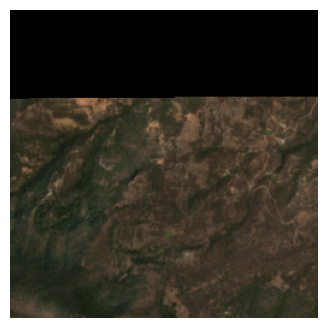

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

sample_path = "/content/drive/MyDrive/computer_vision/tiles_multiband_rgb/tile_rgb_0.png"
img = Image.open(sample_path)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
plt.show()

In [6]:
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

In [7]:
import os
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 1000
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                tile = src.read(window=window)
                tile = np.nan_to_num(tile)

                profile = src.profile.copy()
                profile.update({
                    "driver": "GTiff",
                    "height": win_height,
                    "width": win_width,
                    "transform": src.window_transform(window),
                    "count": src.count,
                    "dtype": tile.dtype
                })

                with rasterio.open(out_path_tif, "w", **profile) as dst:
                    dst.write(tile)

                saved_this_file += 1
                new_saved_total += 1

                if new_saved_total % 200 == 0:
                    print(f"Saved {new_saved_total} new TIFF tiles this run...")

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [8]:
import os
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 1000
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                tile = src.read(window=window)
                tile = np.nan_to_num(tile)

                profile = src.profile.copy()
                profile.update({
                    "driver": "GTiff",
                    "height": win_height,
                    "width": win_width,
                    "transform": src.window_transform(window),
                    "count": src.count,
                    "dtype": tile.dtype
                })

                with rasterio.open(out_path_tif, "w", **profile) as dst:
                    dst.write(tile)

                saved_this_file += 1
                new_saved_total += 1

                if new_saved_total % 200 == 0:
                    print(f"Saved {new_saved_total} new TIFF tiles this run...")

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [9]:
import os
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 1000
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                tile = src.read(window=window)
                tile = np.nan_to_num(tile)

                profile = src.profile.copy()
                profile.update({
                    "driver": "GTiff",
                    "height": win_height,
                    "width": win_width,
                    "transform": src.window_transform(window),
                    "count": src.count,
                    "dtype": tile.dtype
                })

                with rasterio.open(out_path_tif, "w", **profile) as dst:
                    dst.write(tile)

                saved_this_file += 1
                new_saved_total += 1

                if new_saved_total % 200 == 0:
                    print(f"Saved {new_saved_total} new TIFF tiles this run...")

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [10]:
import os
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 1000
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                tile = src.read(window=window)
                tile = np.nan_to_num(tile)

                profile = src.profile.copy()
                profile.update({
                    "driver": "GTiff",
                    "height": win_height,
                    "width": win_width,
                    "transform": src.window_transform(window),
                    "count": src.count,
                    "dtype": tile.dtype
                })

                with rasterio.open(out_path_tif, "w", **profile) as dst:
                    dst.write(tile)

                saved_this_file += 1
                new_saved_total += 1

                if new_saved_total % 200 == 0:
                    print(f"Saved {new_saved_total} new TIFF tiles this run...")

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [11]:
import os
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 1000
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                tile = src.read(window=window)
                tile = np.nan_to_num(tile)

                profile = src.profile.copy()
                profile.update({
                    "driver": "GTiff",
                    "height": win_height,
                    "width": win_width,
                    "transform": src.window_transform(window),
                    "count": src.count,
                    "dtype": tile.dtype
                })

                with rasterio.open(out_path_tif, "w", **profile) as dst:
                    dst.write(tile)

                saved_this_file += 1
                new_saved_total += 1

                if new_saved_total % 200 == 0:
                    print(f"Saved {new_saved_total} new TIFF tiles this run...")

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [12]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 1000
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [13]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 500
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [14]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 500
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [15]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 500
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [16]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 400
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [17]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 300
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [18]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 400
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [19]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 400
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [20]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 400
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [21]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 400
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [22]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 400
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [23]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 400
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [24]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 400
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [25]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 400
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [26]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 200
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [27]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 200
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [28]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 200
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [29]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [30]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [31]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [32]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [33]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [34]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [35]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [36]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [37]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [38]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [39]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [40]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [41]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [42]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [43]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [44]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [45]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [46]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [47]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [48]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [49]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [50]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [51]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [52]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [53]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [54]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [55]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [56]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [57]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [58]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [59]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [60]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [61]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [62]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [63]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [64]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [65]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [66]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [67]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [68]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [69]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [70]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [71]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [72]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [73]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [74]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [75]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [76]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [77]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [78]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [79]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [80]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [81]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [82]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [83]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [84]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [85]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [86]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [87]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [88]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [89]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [90]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [91]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [92]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [93]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [94]:
import os
import gc
import numpy as np
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
output_folder_tif = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

os.makedirs(output_folder_tif, exist_ok=True)

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

tile_size = 256
max_new_tiles_this_run = 100
new_saved_total = 0
stop_now = False

for tif_file in tif_files:
    if stop_now:
        break

    saved_this_file = 0
    skipped_this_file = 0

    with rasterio.open(tif_file) as src:
        print(f"\nProcessing: {os.path.basename(tif_file)}")
        print(f"Band count: {src.count}")

        for row in range(0, src.height, tile_size):
            if stop_now:
                break

            for col in range(0, src.width, tile_size):
                if new_saved_total >= max_new_tiles_this_run:
                    stop_now = True
                    break

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                out_name_tif = f"{os.path.basename(tif_file).replace('.tif', '')}_r{row}_c{col}.tif"
                out_path_tif = os.path.join(output_folder_tif, out_name_tif)

                # Preventing duplicates
                if os.path.exists(out_path_tif):
                    skipped_this_file += 1
                    continue

                try:
                    tile = src.read(window=window)
                    tile = np.nan_to_num(tile)

                    profile = src.profile.copy()
                    profile.update({
                        "driver": "GTiff",
                        "height": win_height,
                        "width": win_width,
                        "transform": src.window_transform(window),
                        "count": src.count,
                        "dtype": tile.dtype
                    })

                    with rasterio.open(out_path_tif, "w", **profile) as dst:
                        dst.write(tile)

                    saved_this_file += 1
                    new_saved_total += 1

                    if new_saved_total % 100 == 0:
                        print(f"Saved {new_saved_total} new TIFF tiles this run...")

                except Exception as e:
                    print(f"Error saving {out_name_tif}: {e}")
                    continue

                finally:
                    if 'tile' in locals():
                        del tile
                    gc.collect()

    print(f"Done: {os.path.basename(tif_file)} | new: {saved_this_file} | skipped existing: {skipped_this_file}")

print(f"\nStopped safely after saving {new_saved_total} new TIFF tiles this run.")


Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000000000-0000023552.tif | new: 0 | skipped existing: 1794

Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000000000.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000011776.tif | new: 0 | skipped existing: 2116

Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Band count: 4
Done: Sentinel2_Mexico_4bands-0000011776-0000023552.tif | new: 0 | skipped existing: 179

In [95]:
import os
print(len(os.listdir("/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band")))
print(len(os.listdir("/content/drive/MyDrive/computer_vision/raw_multiband")))

17161
9


In [96]:
import os
folder = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"
files = [f for f in os.listdir(folder) if f.endswith(".tif")]
print("Total TIFF tiles:", len(files))

Total TIFF tiles: 17161


In [97]:
import rasterio

sample = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band/" + files[0]

with rasterio.open(sample) as src:
    print("Driver:", src.driver)
    print("CRS:", src.crs)
    print("Transform:", src.transform)
    print("Bounds:", src.bounds)

Driver: GTiff
CRS: EPSG:4326
Transform: | 0.00, 0.00,-97.56|
| 0.00,-0.00, 18.59|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=-97.56233991555634, bottom=18.56898540650622, right=-97.53934304428287, top=18.591982277779678)


In [98]:
import numpy as np
import pandas as pd
from rasterio.windows import Window

In [99]:
tile_size = 256
tiles = []

In [100]:
for row in range(0, src.height, tile_size):
    for col in range(0, src.width, tile_size):

        if row + tile_size > src.height or col + tile_size > src.width:
            continue

        window = Window(col, row, tile_size, tile_size)

In [101]:
import os
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window

# folder containing original multiband satellite images
input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
tile_size = 256

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.endswith(".tif")
])

tiles = []

for tif_file in tif_files:
    print("Processing:", os.path.basename(tif_file))

    with rasterio.open(tif_file) as src:
        for row in range(0, src.height, tile_size):
            for col in range(0, src.width, tile_size):

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                # band 1 = B8 (NIR), band 2 = B4 (Red)
                B8_tile = src.read(1, window=window).astype("float32")
                B4_tile = src.read(2, window=window).astype("float32")

                ndvi_tile = (B8_tile - B4_tile) / (B8_tile + B4_tile + 1e-6)
                mean_ndvi = np.nanmean(ndvi_tile)

                transform = src.window_transform(window)
                center_col = win_width / 2
                center_row = win_height / 2
                lon, lat = transform * (center_col, center_row)

                tiles.append({
                    "file": os.path.basename(tif_file),
                    "row": row,
                    "col": col,
                    "lat": lat,
                    "lon": lon,
                    "mean_ndvi": mean_ndvi
                })

df_ndvi = pd.DataFrame(tiles)

print("Shape:", df_ndvi.shape)
df_ndvi.head()

Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Processing: Sentinel2_Mexico_4bands-0000023552-0000000000.tif
Processing: Sentinel2_Mexico_4bands-0000023552-0000011776.tif
Processing: Sentinel2_Mexico_4bands-0000023552-0000023552.tif
Shape: (17161, 6)


,file,row,col,lat,lon,mean_ndvi
0,Sentinel2_Mexico_4bands-0000000000-0000000000.tif,0,0,20.995155,-99.988510,0.475767
1,Sentinel2_Mexico_4bands-0000000000-0000000000.tif,0,256,20.995155,-99.965513,0.386062
2,Sentinel2_Mexico_4bands-0000000000-0000000000.tif,0,512,20.995155,-99.942516,0.277161
3,Sentinel2_Mexico_4bands-0000000000-0000000000.tif,0,768,20.995155,-99.919519,0.264898
4,Sentinel2_Mexico_4bands-0000000000-0000000000.tif,0,1024,20.995155,-99.896522,0.221548


In [102]:
import os
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
tile_size = 256

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.endswith(".tif")
])

tiles = []

for tif_file in tif_files:
    print("Processing:", os.path.basename(tif_file))

    with rasterio.open(tif_file) as src:

        for row in range(0, src.height, tile_size):
            for col in range(0, src.width, tile_size):

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                # NDVI
                B8_tile = src.read(1, window=window).astype("float32")
                B4_tile = src.read(2, window=window).astype("float32")

                ndvi_tile = (B8_tile - B4_tile) / (B8_tile + B4_tile + 1e-6)
                mean_ndvi = np.nanmean(ndvi_tile)

                # coordinates
                transform = src.window_transform(window)
                center_col = win_width / 2
                center_row = win_height / 2
                lon, lat = transform * (center_col, center_row)

                # save
                tiles.append({
                    "tile_id": f"tile_r{row}_c{col}",
                    "row": row,
                    "col": col,
                    "lat": lat,
                    "lon": lon,
                    "mean_ndvi": mean_ndvi
                })

df_ndvi = pd.DataFrame(tiles)

print("Shape:", df_ndvi.shape)
print(df_ndvi.head())

df_ndvi.to_csv("/content/drive/MyDrive/computer_vision/ndvi_tiles_dataset.csv", index=False)
print("Saved NDVI dataset")

Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Processing: Sentinel2_Mexico_4bands-0000023552-0000000000.tif
Processing: Sentinel2_Mexico_4bands-0000023552-0000011776.tif
Processing: Sentinel2_Mexico_4bands-0000023552-0000023552.tif
Shape: (17161, 6)
         tile_id  row   col        lat        lon  mean_ndvi
0     tile_r0_c0    0     0  20.995155 -99.988510   0.475767
1   tile_r0_c256    0   256  20.995155 -99.965513   0.386062
2   tile_r0_c512    0   512  20.995155 -99.942516   0.277161
3   tile_r0_c768    0   768  20.995155 -99.919519   0.264898
4  tile_r0_c1024    0  1024  20.995155 -99.896522   0.221548
Saved NDVI dataset


In [103]:
# Old attempt — ignore
df = pd.DataFrame(tiles)
df.head()

,tile_id,row,col,lat,lon,mean_ndvi
0,tile_r0_c0,0,0,20.995155,-99.988510,0.475767
1,tile_r0_c256,0,256,20.995155,-99.965513,0.386062
2,tile_r0_c512,0,512,20.995155,-99.942516,0.277161
3,tile_r0_c768,0,768,20.995155,-99.919519,0.264898
4,tile_r0_c1024,0,1024,20.995155,-99.896522,0.221548


In [104]:
df.shape

(17161, 6)

In [105]:
with rasterio.open(tif_file) as src:
    for row in range(0, src.height, tile_size):
        for col in range(0, src.width, tile_size):

            win_width = min(tile_size, src.width - col)
            win_height = min(tile_size, src.height - row)
            window = Window(col, row, win_width, win_height)

            B8_tile = src.read(1, window=window).astype("float32")
            B4_tile = src.read(2, window=window).astype("float32")

print(df.shape)
df.head()

(17161, 6)


,tile_id,row,col,lat,lon,mean_ndvi
0,tile_r0_c0,0,0,20.995155,-99.988510,0.475767
1,tile_r0_c256,0,256,20.995155,-99.965513,0.386062
2,tile_r0_c512,0,512,20.995155,-99.942516,0.277161
3,tile_r0_c768,0,768,20.995155,-99.919519,0.264898
4,tile_r0_c1024,0,1024,20.995155,-99.896522,0.221548


In [106]:
import os

folder = "/content/drive/MyDrive/computer_vision/raw_multiband"

tif_files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".tif")]

print(len(tif_files))
tif_files[:3]

9


['/content/drive/MyDrive/computer_vision/raw_multiband/Sentinel2_Mexico_4bands-0000000000-0000000000.tif',
 '/content/drive/MyDrive/computer_vision/raw_multiband/Sentinel2_Mexico_4bands-0000000000-0000011776.tif',
 '/content/drive/MyDrive/computer_vision/raw_multiband/Sentinel2_Mexico_4bands-0000000000-0000023552.tif']

In [107]:
all_tiles = []

for file in tif_files:
    src = rasterio.open(file)

    for row in range(0, src.height, tile_size):
        for col in range(0, src.width, tile_size):

            if row + tile_size > src.height or col + tile_size > src.width:
                continue

            window = Window(col, row, tile_size, tile_size)

            B8_tile = src.read(1, window=window).astype("float32")
            B4_tile = src.read(2, window=window).astype("float32")

            ndvi_tile = (B8_tile - B4_tile) / (B8_tile + B4_tile + 1e-6)
            mean_ndvi = np.nanmean(ndvi_tile)

            transform = src.window_transform(window)
            center_col = tile_size // 2
            center_row = tile_size // 2
            lon, lat = transform * (center_col, center_row)

            all_tiles.append({
                "file": file.split("/")[-1],
                "row": row,
                "col": col,
                "lat": lat,
                "lon": lon,
                "mean_ndvi": mean_ndvi
            })

In [108]:
df_all = pd.DataFrame(all_tiles)

print(df_all.shape)
df_all.head()

(16900, 6)


,file,row,col,lat,lon,mean_ndvi
0,Sentinel2_Mexico_4bands-0000000000-0000000000.tif,0,0,20.995155,-99.988510,0.475767
1,Sentinel2_Mexico_4bands-0000000000-0000000000.tif,0,256,20.995155,-99.965513,0.386062
2,Sentinel2_Mexico_4bands-0000000000-0000000000.tif,0,512,20.995155,-99.942516,0.277161
3,Sentinel2_Mexico_4bands-0000000000-0000000000.tif,0,768,20.995155,-99.919519,0.264898
4,Sentinel2_Mexico_4bands-0000000000-0000000000.tif,0,1024,20.995155,-99.896522,0.221548


In [109]:
# FAKE DATA (for testing only)
import numpy as np
df_all_fake = df_all.copy()

In [110]:
df_all = df_all.drop(columns=["rainfall", "temperature", "stress_index"], errors="ignore")

In [111]:
df_final = df_all.copy()
df_final.head()

,file,row,col,lat,lon,mean_ndvi
0,Sentinel2_Mexico_4bands-0000000000-0000000000.tif,0,0,20.995155,-99.988510,0.475767
1,Sentinel2_Mexico_4bands-0000000000-0000000000.tif,0,256,20.995155,-99.965513,0.386062
2,Sentinel2_Mexico_4bands-0000000000-0000000000.tif,0,512,20.995155,-99.942516,0.277161
3,Sentinel2_Mexico_4bands-0000000000-0000000000.tif,0,768,20.995155,-99.919519,0.264898
4,Sentinel2_Mexico_4bands-0000000000-0000000000.tif,0,1024,20.995155,-99.896522,0.221548


In [112]:
# Computimg NDVI and NDWI from Sentinel-2 multi-band satellite tiles
# Extracting spatial coordinates (lat, lon) for each tile
# Building a structured dataset for environmental stress analysis

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
tile_size = 256

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.endswith(".tif")
])

tiles = []

for tif_file in tif_files:
    print("Processing:", os.path.basename(tif_file))

    with rasterio.open(tif_file) as src:

        for row in range(0, src.height, tile_size):
            for col in range(0, src.width, tile_size):

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                # Bands
                B8 = src.read(1, window=window).astype("float32")  # NIR
                B4 = src.read(2, window=window).astype("float32")  # Red
                B3 = src.read(3, window=window).astype("float32")  # Green

                # NDVI
                ndvi = (B8 - B4) / (B8 + B4 + 1e-6)
                mean_ndvi = np.nanmean(ndvi)

                # NDWI
                ndwi = (B3 - B8) / (B3 + B8 + 1e-6)
                mean_ndwi = np.nanmean(ndwi)

                # Coordinates
                transform = src.window_transform(window)
                center_col = win_width / 2
                center_row = win_height / 2
                lon, lat = transform * (center_col, center_row)

                # Save
                tiles.append({
                    "tile_id": f"tile_r{row}_c{col}",
                    "lat": lat,
                    "lon": lon,
                    "mean_ndvi": mean_ndvi,
                    "mean_ndwi": mean_ndwi
                })

df = pd.DataFrame(tiles)

print("Shape:", df.shape)
print(df.head())

df.to_csv("/content/drive/MyDrive/computer_vision/ndvi_ndwi_dataset.csv", index=False)
print("Saved NDVI + NDWI dataset")

Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Processing: Sentinel2_Mexico_4bands-0000023552-0000000000.tif
Processing: Sentinel2_Mexico_4bands-0000023552-0000011776.tif
Processing: Sentinel2_Mexico_4bands-0000023552-0000023552.tif
Shape: (17161, 5)
         tile_id        lat        lon  mean_ndvi  mean_ndwi
0     tile_r0_c0  20.995155 -99.988510   0.475767  -0.516406
1   tile_r0_c256  20.995155 -99.965513   0.386062  -0.427808
2   tile_r0_c512  20.995155 -99.942516   0.277161  -0.336298
3   tile_r0_c768  20.995155 -99.919519   0.264898  -0.330540
4  tile_r0_c1024  20.995155 -99.896522   0.221548  -0.304224
Saved NDVI + NDWI dataset


In [113]:
# Computing NDVI, NDWI, EVI, and NDBI from Sentinel-2 multi-band satellite tiles
# Extracting tile center coordinates (lat, lon)
# Building a structured dataset for environmental stress analysis

input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
tile_size = 256

tif_files = sorted([
    os.path.join(input_folder, f)
    for f in os.listdir(input_folder)
    if f.endswith(".tif")
])

tiles = []

for tif_file in tif_files:
    print("Processing:", os.path.basename(tif_file))

    with rasterio.open(tif_file) as src:
        for row in range(0, src.height, tile_size):
            for col in range(0, src.width, tile_size):

                win_width = min(tile_size, src.width - col)
                win_height = min(tile_size, src.height - row)
                window = Window(col, row, win_width, win_height)

                # Sentinel-2 bands from your exported file
                B8 = src.read(1, window=window).astype("float32")  # NIR
                B4 = src.read(2, window=window).astype("float32")  # Red
                B3 = src.read(3, window=window).astype("float32")  # Green
                B2 = src.read(4, window=window).astype("float32")  # Blue

                # NDVI
                ndvi = (B8 - B4) / (B8 + B4 + 1e-6)
                mean_ndvi = np.nanmean(ndvi)

                # NDWI
                ndwi = (B3 - B8) / (B3 + B8 + 1e-6)
                mean_ndwi = np.nanmean(ndwi)

                # EVI
                evi = 2.5 * (B8 - B4) / (B8 + 6 * B4 - 7.5 * B2 + 1 + 1e-6)
                evi = np.clip(evi, -1, 1)   # optional safety clip
                mean_evi = np.nanmean(evi)



                # Coordinates
                transform = src.window_transform(window)
                center_col = win_width / 2
                center_row = win_height / 2
                lon, lat = transform * (center_col, center_row)

                # Save row
                tiles.append({
                    "tile_id": f"tile_r{row}_c{col}",
                    "lat": lat,
                    "lon": lon,
                    "mean_ndvi": mean_ndvi,
                    "mean_ndwi": mean_ndwi,
                    "mean_evi": mean_evi,
                })

df_features = pd.DataFrame(tiles)

print("Shape:", df_features.shape)
print(df_features.head())

df_features.to_csv("/content/drive/MyDrive/computer_vision/ndvi_ndwi_evi_dataset.csv", index=False)
print("Saved NDVI + NDWI + EVI dataset")

Processing: Sentinel2_Mexico_4bands-0000000000-0000000000.tif
Processing: Sentinel2_Mexico_4bands-0000000000-0000011776.tif
Processing: Sentinel2_Mexico_4bands-0000000000-0000023552.tif
Processing: Sentinel2_Mexico_4bands-0000011776-0000000000.tif
Processing: Sentinel2_Mexico_4bands-0000011776-0000011776.tif
Processing: Sentinel2_Mexico_4bands-0000011776-0000023552.tif
Processing: Sentinel2_Mexico_4bands-0000023552-0000000000.tif
Processing: Sentinel2_Mexico_4bands-0000023552-0000011776.tif
Processing: Sentinel2_Mexico_4bands-0000023552-0000023552.tif
Shape: (17161, 6)
         tile_id        lat        lon  mean_ndvi  mean_ndwi  mean_evi
0     tile_r0_c0  20.995155 -99.988510   0.475767  -0.516406  0.912242
1   tile_r0_c256  20.995155 -99.965513   0.386062  -0.427808  0.927367
2   tile_r0_c512  20.995155 -99.942516   0.277161  -0.336298  0.793974
3   tile_r0_c768  20.995155 -99.919519   0.264898  -0.330540  0.765042
4  tile_r0_c1024  20.995155 -99.896522   0.221548  -0.304224  0.56940

In [114]:
print(df_features[["mean_ndvi", "mean_ndwi", "mean_evi"]].describe())

          mean_ndvi     mean_ndwi      mean_evi
count  17161.000000  17161.000000  17161.000000
mean       0.430040     -0.459140      0.774105
std        0.196862      0.160147      0.201516
min       -0.334694     -0.740684      0.028233
25%        0.284255     -0.576822      0.635367
50%        0.385599     -0.453913      0.800236
75%        0.601979     -0.366554      0.970594
max        0.845434      0.614958      1.000000


In [115]:
import xarray as xr

# Load ERA5 dataset
path = "/content/drive/MyDrive/computer_vision/climate_data/era5_mexico_2023_monthly.nc"
ds = xr.open_dataset(path)

# Convert to dataframe
df_climate = ds.to_dataframe().reset_index()

print(df_climate.head())

  valid_time  latitude  longitude         t2m        tp  number expver
0 2023-01-01      21.0     -100.0  287.576416  0.000038       0   0001
1 2023-01-01      21.0      -99.9  289.199463  0.000038       0   0001
2 2023-01-01      21.0      -99.8  289.742432  0.000047       0   0001
3 2023-01-01      21.0      -99.7  288.965088  0.000056       0   0001
4 2023-01-01      21.0      -99.6  288.379150  0.000061       0   0001


In [116]:
df_climate["temperature"] = df_climate["t2m"] - 273.15
df_climate["rainfall"] = df_climate["tp"] * 1000

df_climate["spi"] = (
    df_climate.groupby(["latitude", "longitude"])["rainfall"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

In [117]:
df_spi_final = (
    df_climate.groupby(["latitude", "longitude"], as_index=False)
    .agg({
        "spi": "min",
        "temperature": "mean"
    })
)

df_spi_final = df_spi_final.rename(columns={
    "latitude": "lat",
    "longitude": "lon",
    "spi": "spi_min"
})

print(df_spi_final.head())

    lat    lon   spi_min  temperature
0  18.0 -100.0 -0.735733    27.080536
1  18.0  -99.9 -0.741728    26.514292
2  18.0  -99.8 -0.747540    25.932098
3  18.0  -99.7 -0.741615    26.397268
4  18.0  -99.6 -0.752252    26.884085


In [118]:
import pandas as pd
import numpy as np

# load corrected satellite dataset
df_sat = pd.read_csv("/content/drive/MyDrive/computer_vision/ndvi_ndwi_evi_dataset.csv")
df_sat = df_sat[["tile_id", "lat", "lon", "mean_ndvi", "mean_ndwi", "mean_evi"]].copy()

# keep only needed climate columns
df_spi_final = df_spi_final[["lat", "lon", "spi_min", "temperature"]].copy()

# nearest-neighbor match
sat_coords = df_sat[["lat", "lon"]].to_numpy()
clim_coords = df_spi_final[["lat", "lon"]].to_numpy()

diff = sat_coords[:, None, :] - clim_coords[None, :, :]
dist2 = np.sum(diff**2, axis=2)
nearest_idx = np.argmin(dist2, axis=1)

# final merged dataset
df_final_spi = df_sat.copy()
df_final_spi["spi_min"] = df_spi_final.iloc[nearest_idx]["spi_min"].to_numpy()
df_final_spi["temperature"] = df_spi_final.iloc[nearest_idx]["temperature"].to_numpy()

print(df_final_spi.shape)
print(df_final_spi.head())

df_final_spi.to_csv(
    "/content/drive/MyDrive/computer_vision/complete_multimodal_dataset_spi.csv",
    index=False
)

print("SPI-based dataset saved")

(17161, 8)
         tile_id        lat        lon  mean_ndvi  mean_ndwi  mean_evi  \
0     tile_r0_c0  20.995155 -99.988510   0.475767  -0.516406  0.912242   
1   tile_r0_c256  20.995155 -99.965513   0.386062  -0.427808  0.927367   
2   tile_r0_c512  20.995155 -99.942516   0.277161  -0.336299  0.793974   
3   tile_r0_c768  20.995155 -99.919519   0.264898  -0.330540  0.765042   
4  tile_r0_c1024  20.995155 -99.896522   0.221548  -0.304224  0.569407   

    spi_min  temperature  
0 -1.226828    17.748343  
1 -1.226828    17.748343  
2 -1.267636    19.512014  
3 -1.267636    19.512014  
4 -1.267636    19.512014  
SPI-based dataset saved


In [119]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/computer_vision/complete_multimodal_dataset_spi.csv")

df["stress"] = (
    (df["mean_ndvi"] < 0.3) &
    (df["spi_min"] < -1)
).astype(int)

print(df["stress"].value_counts())

stress
0    13201
1     3960
Name: count, dtype: int64


In [120]:
X = df[["mean_ndwi", "mean_evi", "temperature"]]
y = df["stress"]

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      2641
           1       0.88      0.96      0.92       792

    accuracy                           0.96      3433
   macro avg       0.94      0.96      0.95      3433
weighted avg       0.96      0.96      0.96      3433



mean_ndwi      0.473929
mean_evi       0.362667
temperature    0.163403
dtype: float64


<Axes: >

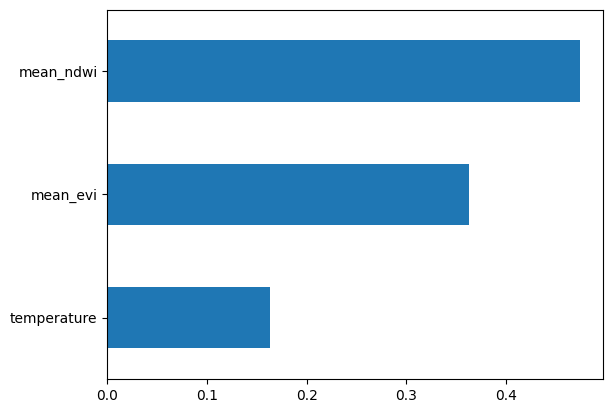

In [121]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))
importance.sort_values().plot(kind="barh")

In [122]:
df.to_csv("/content/drive/MyDrive/computer_vision/complete_multimodal_dataset_spi_labeled.csv", index=False)
print("labeled SPI dataset saved")

labeled SPI dataset saved


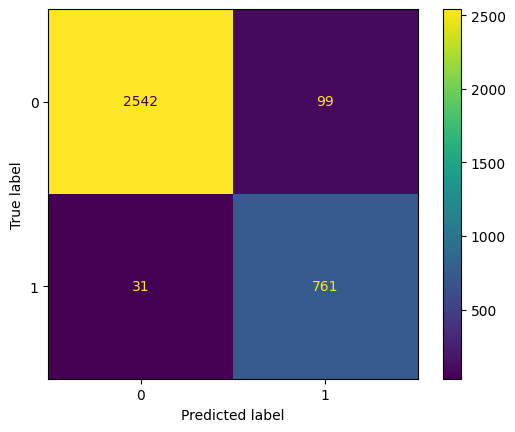

In [123]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [124]:
plt.savefig("/content/drive/MyDrive/computer_vision/confusion_matrix.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [125]:
# adding temporary features
# Extract month
df_climate["month"] = pd.to_datetime(df_climate["valid_time"]).dt.month

In [126]:
# computing seaasonal pattern
df_season = (
    df_climate.groupby(["latitude", "longitude", "month"])["spi"]
    .mean()
    .reset_index()
)

In [127]:
# Computing variability (stress instability)
df_variability = (
    df_climate.groupby(["latitude", "longitude"])["spi"]
    .std()
    .reset_index()
)

df_variability = df_variability.rename(columns={"spi": "spi_std"})

In [128]:
df_variability = df_variability.rename(columns={
    "latitude": "lat",
    "longitude": "lon"
})

print(df_variability.head())

    lat    lon  spi_std
0  18.0 -100.0      1.0
1  18.0  -99.9      1.0
2  18.0  -99.8      1.0
3  18.0  -99.7      1.0
4  18.0  -99.6      1.0


In [129]:
df_spi_full = pd.merge(
    df_spi_final,
    df_variability,
    on=["lat", "lon"],
    how="left"
)

print(df_spi_full.head())
print(df_spi_full.shape)

    lat    lon   spi_min  temperature  spi_std
0  18.0 -100.0 -0.735733    27.080536      1.0
1  18.0  -99.9 -0.741728    26.514292      1.0
2  18.0  -99.8 -0.747540    25.932098      1.0
3  18.0  -99.7 -0.741615    26.397268      1.0
4  18.0  -99.6 -0.752252    26.884085      1.0
(961, 5)


In [130]:
import numpy as np
import pandas as pd

# satellite points
sat_coords = df_sat[["lat", "lon"]].to_numpy()

# climate points
clim_coords = df_spi_full[["lat", "lon"]].to_numpy()

# nearest match
diff = sat_coords[:, None, :] - clim_coords[None, :, :]
dist2 = np.sum(diff**2, axis=2)
nearest_idx = np.argmin(dist2, axis=1)

# build final merged dataset
df = df_sat.copy()
df["spi_min"] = df_spi_full.iloc[nearest_idx]["spi_min"].to_numpy()
df["temperature"] = df_spi_full.iloc[nearest_idx]["temperature"].to_numpy()
df["spi_std"] = df_spi_full.iloc[nearest_idx]["spi_std"].to_numpy()

print(df.head())
print(df.shape)

         tile_id        lat        lon  mean_ndvi  mean_ndwi  mean_evi  \
0     tile_r0_c0  20.995155 -99.988510   0.475767  -0.516406  0.912242   
1   tile_r0_c256  20.995155 -99.965513   0.386062  -0.427808  0.927367   
2   tile_r0_c512  20.995155 -99.942516   0.277161  -0.336299  0.793974   
3   tile_r0_c768  20.995155 -99.919519   0.264898  -0.330540  0.765042   
4  tile_r0_c1024  20.995155 -99.896522   0.221548  -0.304224  0.569407   

    spi_min  temperature  spi_std  
0 -1.226828    17.748343      1.0  
1 -1.226828    17.748343      1.0  
2 -1.267636    19.512014      1.0  
3 -1.267636    19.512014      1.0  
4 -1.267636    19.512014      1.0  
(17161, 9)


In [131]:
(df["mean_ndvi"] < 0.3) & (df["spi_min"] < -1)

,0
0,False
1,False
2,True
3,True
4,True
...,...
17156,False
17157,True
17158,True
17159,False


In [132]:
df["stress"] = (
    (df["mean_ndvi"] < 0.3) &          # vegetation weak
    (df["spi_min"] < -1) &             # drought present
    (df["spi_std"] > 0.5)              # unstable climate
).astype(int)

print(df["stress"].value_counts())

stress
0    13201
1     3960
Name: count, dtype: int64


In [133]:
# features for temporal-aware model
X = df[["mean_ndwi", "mean_evi", "temperature", "spi_std"]]
y = df["stress"]

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2641
           1       0.90      0.96      0.93       792

    accuracy                           0.97      3433
   macro avg       0.94      0.96      0.95      3433
weighted avg       0.97      0.97      0.97      3433



mean_ndwi      0.568341
mean_evi       0.286340
temperature    0.131128
spi_std        0.014192
dtype: float64


<Axes: >

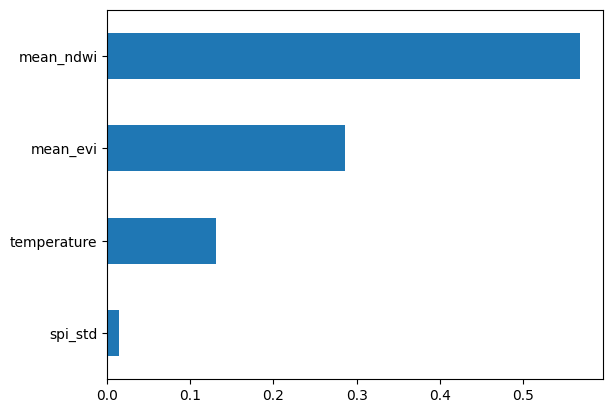

In [134]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))
importance.sort_values().plot(kind="barh")

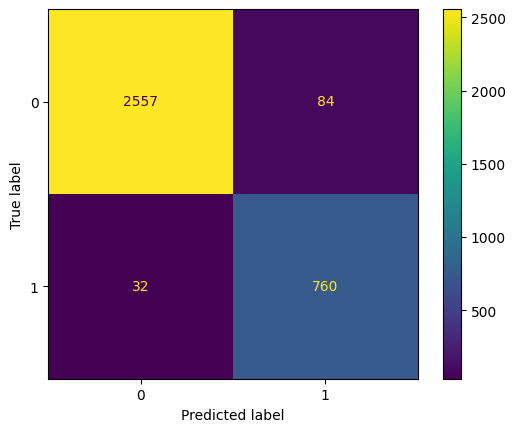

In [135]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

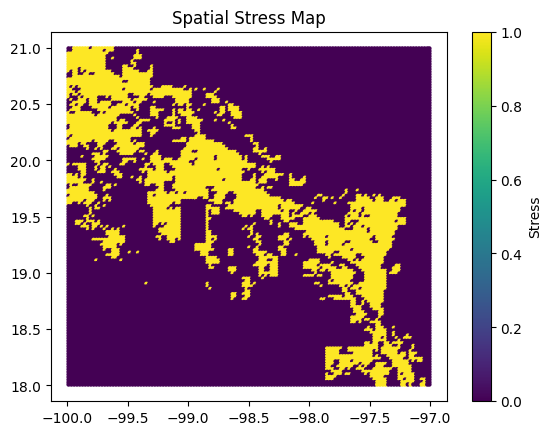

In [136]:
import matplotlib.pyplot as plt

plt.scatter(df["lon"], df["lat"], c=df["stress"], s=5)
plt.colorbar(label="Stress")
plt.title("Spatial Stress Map")
plt.show()

<Axes: xlabel='month'>

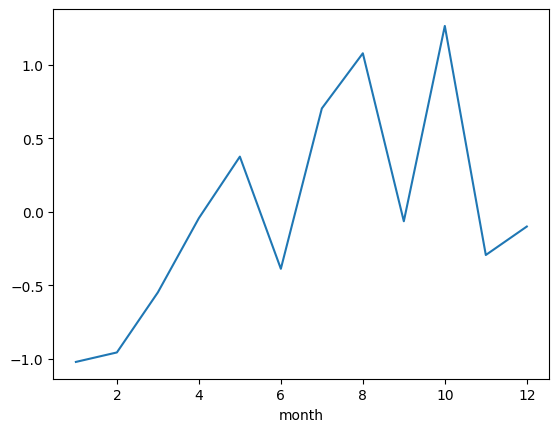

In [137]:
df_climate.groupby("month")["spi"].mean().plot()

In [138]:
# anomaly score based on SPI
df["spi_anomaly"] = (df["spi_min"] - df["spi_min"].mean()) / df["spi_min"].std()

# flag extreme drought
df["anomaly"] = (df["spi_anomaly"] < -2).astype(int)

print(df["anomaly"].value_counts())

anomaly
0    16662
1      499
Name: count, dtype: int64


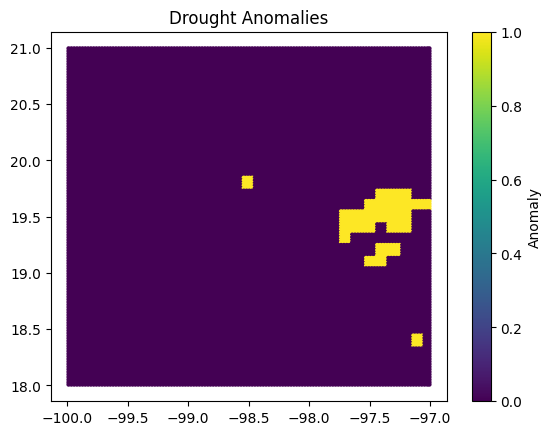

In [139]:
plt.scatter(df["lon"], df["lat"], c=df["anomaly"], s=5)
plt.colorbar(label="Anomaly")
plt.title("Drought Anomalies")
plt.show()

In [140]:
df["priority_score"] = (
    (-df["spi_min"]) * 0.5 +      # drought severity
    (df["spi_std"]) * 0.3 +       # instability
    (1 - df["mean_ndvi"]) * 0.2   # vegetation weakness
)

# top high-risk regions
df_sorted = df.sort_values(by="priority_score", ascending=False)

df_sorted.head(10)

,tile_id,lat,lon,mean_ndvi,mean_ndwi,mean_evi,spi_min,temperature,spi_std,stress,spi_anomaly,anomaly,priority_score
10866,tile_r3840_c5888,19.592346,-97.343870,0.123319,-0.235655,0.251620,-1.709700,14.068980,1.0,1,-3.020241,1,1.330186
10905,tile_r4096_c5888,19.569349,-97.343870,0.124503,-0.238138,0.250636,-1.709700,14.068980,1.0,1,-3.020241,1,1.329949
11451,tile_r7680_c5888,19.247393,-97.343870,0.098502,-0.207898,0.200731,-1.697274,10.779266,1.0,1,-2.961532,1,1.328937
10907,tile_r4096_c6400,19.569349,-97.297876,0.150626,-0.279693,0.288394,-1.709700,14.068980,1.0,1,-3.020241,1,1.324725
10828,tile_r3584_c6144,19.615343,-97.320873,0.153727,-0.265950,0.301550,-1.709700,14.068980,1.0,1,-3.020241,1,1.324105
10909,tile_r4096_c6912,19.569349,-97.251882,0.154783,-0.245858,0.364910,-1.709700,14.068980,1.0,1,-3.020241,1,1.323893
10867,tile_r3840_c6144,19.592346,-97.320873,0.160934,-0.273481,0.322812,-1.709700,14.068980,1.0,1,-3.020241,1,1.322663
10827,tile_r3584_c5888,19.615343,-97.343870,0.163575,-0.255587,0.366831,-1.709700,14.068980,1.0,1,-3.020241,1,1.322135
10906,tile_r4096_c6144,19.569349,-97.320873,0.172198,-0.287825,0.330889,-1.709700,14.068980,1.0,1,-3.020241,1,1.320410
11452,tile_r7680_c6144,19.247393,-97.320873,0.164272,-0.275122,0.318403,-1.697274,10.779266,1.0,1,-2.961532,1,1.315783


<Axes: >

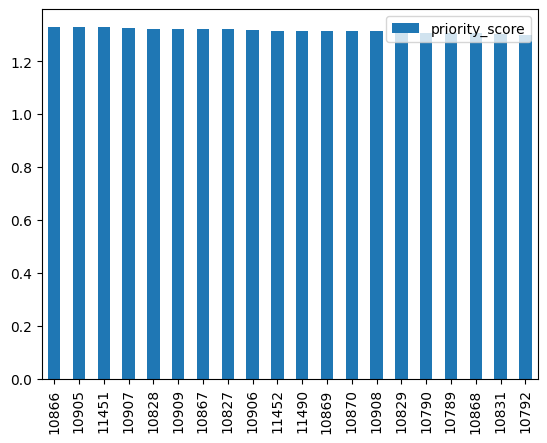

In [141]:
df_sorted.head(20).plot(kind="bar", y="priority_score")

In [142]:
# Cross-validation
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
scores = cross_val_score(model, X, y, cv=5)  # 5-fold cross-validation
print(f'Cross-validation scores: {scores}')
print(f'Mean accuracy: {scores.mean()}')

Cross-validation scores: [0.93882901 0.9009324  0.91958042 0.9763986  0.90530303]
Mean accuracy: 0.9282086929479881


In [143]:
# XGBoost
import xgboost as xgb

model = xgb.XGBClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [144]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(estimator=xgb.XGBClassifier(), param_grid=param_grid, cv=3)
grid_search.fit(X_train, y_train)
print(f'Best parameters: {grid_search.best_params_}')

Best parameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200}


# Adding Time-series or Spatial Modeling (LSTM/CNN)

In [145]:
# LSTM
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense


# Selecting the relevant features for the LSTM model
X = df[["mean_ndvi", "mean_evi", "temperature", "spi_std"]].values
y = df["stress"].values  # Assuming you are predicting the "stress" column

# Scaling the features using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(X)

# Preparing the data for LSTM
def create_lstm_data(data, time_steps=10):
    X_data, y_data = [], []
    for i in range(time_steps, len(data)):
        X_data.append(data[i-time_steps:i])  # Collect previous 'time_steps' values
        y_data.append(data[i])  # Collect the current value
    return np.array(X_data), np.array(y_data)

X_lstm, y_lstm = create_lstm_data(scaled_data)

# Create the LSTM model
model = Sequential()

# Add LSTM layers using 50 units
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_lstm.shape[1], X_lstm.shape[2])))
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Add the output layer
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Fit the model (Training the model with scaled data)
model.fit(X_lstm, y_lstm, epochs=10, batch_size=32)

# Predictions
y_pred = model.predict(X_lstm)



Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


536/536 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: nan
Epoch 2/10
536/536 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: nan
Epoch 3/10
536/536 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: nan
Epoch 4/10
536/536 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: nan
Epoch 5/10
536/536 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: nan
Epoch 6/10
536/536 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: nan
Epoch 7/10
536/536 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: nan
Epoch 8/10
536/536 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: nan
Epoch 9/10
536/536 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: nan
Epoch 10/10
536/536 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: nan
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


# CNN Implementation

In [146]:
import os
import numpy as np
import rasterio
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Creating RGB previews from your 4-band spatialCreate RGB previews from your 4-band spatial

In [147]:
import os
import numpy as np
import rasterio

input_folder = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"

tiff_files = sorted([
    f for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

sample_file = os.path.join(input_folder, tiff_files[0])

with rasterio.open(sample_file) as src:
    img = src.read()
    print("Shape:", img.shape)
    for i in range(img.shape[0]):
        band = img[i]
        print(
            f"Band {i}: min={band.min()}, max={band.max()}, "
            f"mean={band.mean():.2f}, p2={np.percentile(band,2):.2f}, "
            f"p98={np.percentile(band,98):.2f}"
        )

Shape: (4, 256, 256)
Band 0: min=0.0, max=4017.0, mean=1481.89, p2=0.00, p98=2755.00
Band 1: min=0.0, max=2149.0, mean=530.52, p2=0.00, p98=1252.40
Band 2: min=0.0, max=1739.0, mean=471.35, p2=0.00, p98=993.53
Band 3: min=0.0, max=1555.0, mean=347.09, p2=0.00, p98=748.80


Number of TIFF files found: 17161
Sample file: Sentinel2_Mexico_4bands-0000000000-0000000000_r0_c0.tif
RGB preview shape: (256, 256, 3)
RGB dtype: uint8


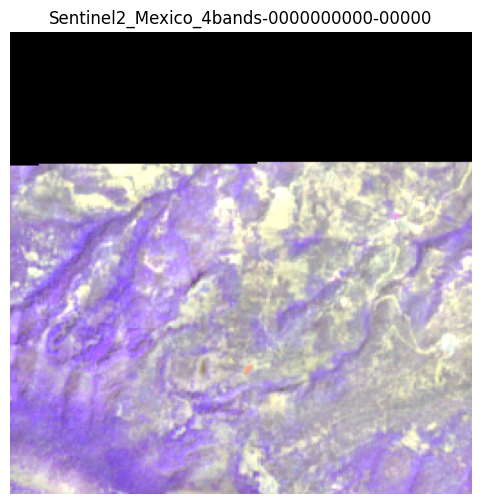

In [148]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# Paths
input_folder = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"
preview_folder = "/content/drive/MyDrive/computer_vision/spatial_rgb"

os.makedirs(preview_folder, exist_ok=True)

tiff_files = sorted([
    f for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

print("Number of TIFF files found:", len(tiff_files))


def tiff_to_rgb_preview(tiff_path):
    with rasterio.open(tiff_path) as src:
        img = src.read()

    blue = img[0].astype(np.float32)
    green = img[1].astype(np.float32)
    red = img[2].astype(np.float32)

    rgb = np.stack([red, green, blue], axis=-1)

    # Normalizing each channel independently
    for i in range(3):
        ch = rgb[:, :, i]
        p2 = np.percentile(ch, 2)
        p98 = np.percentile(ch, 98)
        rgb[:, :, i] = np.clip((ch - p2) / (p98 - p2 + 1e-8), 0, 1)

    # Gamma correction
    rgb = np.power(rgb, 1 / 1.4)

    return (rgb * 255).astype(np.uint8)


# Test on one image only
sample_name = tiff_files[0]
sample_path = os.path.join(input_folder, sample_name)

rgb = tiff_to_rgb_preview(sample_path)

print("Sample file:", sample_name)
print("RGB preview shape:", rgb.shape)
print("RGB dtype:", rgb.dtype)

plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.title(sample_name[:40])
plt.axis("off")
plt.show()

Sample file: Sentinel2_Mexico_4bands-0000000000-0000000000_r0_c0.tif
RGB preview shape: (256, 256, 3)
RGB dtype: uint8


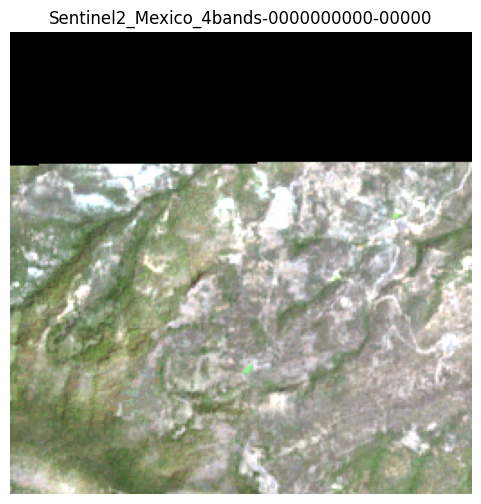

In [149]:
def tiff_to_false_color(tiff_path):
    import numpy as np
    import rasterio

    with rasterio.open(tiff_path) as src:
        img = src.read()

    # Extract bands
    blue = img[0].astype(np.float32)
    green = img[1].astype(np.float32)
    red = img[2].astype(np.float32)
    nir = img[3].astype(np.float32)

    # False color mapping
    rgb = np.stack([nir, red, green], axis=-1)

    # Normalizing each channel independently
    for i in range(3):
        ch = rgb[:, :, i]
        p2 = np.percentile(ch, 2)
        p98 = np.percentile(ch, 98)
        rgb[:, :, i] = np.clip((ch - p2) / (p98 - p2 + 1e-8), 0, 1)

    return (rgb * 255).astype(np.uint8)

    # Test on one image only
sample_name = tiff_files[0]
sample_path = os.path.join(input_folder, sample_name)

rgb = tiff_to_false_color(sample_path)

print("Sample file:", sample_name)
print("RGB preview shape:", rgb.shape)
print("RGB dtype:", rgb.dtype)

plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.title(sample_name[:40])
plt.axis("off")
plt.show()

In [150]:
from PIL import Image

test_folder = "/content/drive/MyDrive/computer_vision/spatial_rgb_test"
os.makedirs(test_folder, exist_ok=True)

for fname in tiff_files[:5]:
    path = os.path.join(input_folder, fname)
    rgb = tiff_to_false_color(path)

    out_path = os.path.join(test_folder, fname.replace(".tif", ".png"))
    Image.fromarray(rgb).save(out_path)

    print("Saved:", out_path)

Saved: /content/drive/MyDrive/computer_vision/spatial_rgb_test/Sentinel2_Mexico_4bands-0000000000-0000000000_r0_c0.png
Saved: /content/drive/MyDrive/computer_vision/spatial_rgb_test/Sentinel2_Mexico_4bands-0000000000-0000000000_r0_c1024.png
Saved: /content/drive/MyDrive/computer_vision/spatial_rgb_test/Sentinel2_Mexico_4bands-0000000000-0000000000_r0_c10240.png
Saved: /content/drive/MyDrive/computer_vision/spatial_rgb_test/Sentinel2_Mexico_4bands-0000000000-0000000000_r0_c10496.png
Saved: /content/drive/MyDrive/computer_vision/spatial_rgb_test/Sentinel2_Mexico_4bands-0000000000-0000000000_r0_c10752.png


In [151]:
import os

base_label_folder = "/content/drive/MyDrive/computer_vision/spatial_labeled"
veg_folder = os.path.join(base_label_folder, "vegetation")
nonveg_folder = os.path.join(base_label_folder, "non_vegetation")

os.makedirs(veg_folder, exist_ok=True)
os.makedirs(nonveg_folder, exist_ok=True)

print("Folders created")

Folders created


In [152]:
from PIL import Image
import os


# Paths
input_folder = "/content/drive/MyDrive/computer_vision/raw_multiband"
preview_folder = "/content/drive/MyDrive/computer_vision/spatial_rgb"

os.makedirs(preview_folder, exist_ok=True)


# List TIFF files

tiff_files = sorted([
    f for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

print("Total TIFF files:", len(tiff_files))


# SKIP IF ALREADY DONE

existing_previews = [
    f for f in os.listdir(preview_folder)
    if f.lower().endswith(".png")
]

if len(existing_previews) > 0:
    print(f" Found {len(existing_previews)} previews already. Skipping generation.")

else:
    print("🚀 Generating previews...")

    for i, fname in enumerate(tiff_files):
        tiff_path = os.path.join(input_folder, fname)

        try:
            # Convert TIFF → RGB
            rgb = tiff_to_false_color(tiff_path)

            out_path = os.path.join(
                preview_folder,
                fname.replace(".tif", ".png")
            )


            if not os.path.exists(out_path):
                Image.fromarray(rgb).save(out_path, format="PNG")

        except Exception as e:
            print(f" Skipping {fname}: {e}")

        if i % 500 == 0:
            print(f"Saved {i}/{len(tiff_files)}")

    print(" All previews saved.")

Total TIFF files: 9
 Found 17161 previews already. Skipping generation.


In [153]:
# Building the labels CSV
import os
import pandas as pd

base_label_folder = "/content/drive/MyDrive/computer_vision/spatial_labeled"
veg_folder = os.path.join(base_label_folder, "vegetation")
nonveg_folder = os.path.join(base_label_folder, "non_vegetation")

records = []

for fname in os.listdir(veg_folder):
    if fname.lower().endswith(".png"):
        tiff_name = os.path.splitext(fname)[0] + ".tif"
        records.append({"tile_name": tiff_name, "label": 1})

for fname in os.listdir(nonveg_folder):
    if fname.lower().endswith(".png"):
        tiff_name = os.path.splitext(fname)[0] + ".tif"
        records.append({"tile_name": tiff_name, "label": 0})

labels_df = pd.DataFrame(records)

labels_csv_path = "/content/drive/MyDrive/computer_vision/spatial_labels.csv"
labels_df.to_csv(labels_csv_path, index=False)

print("Saved labels CSV to:", labels_csv_path)
print("Total labeled samples:", len(labels_df))
print(labels_df["label"].value_counts())
print(labels_df.head())

Saved labels CSV to: /content/drive/MyDrive/computer_vision/spatial_labels.csv
Total labeled samples: 200
label
1    100
0    100
Name: count, dtype: int64
                                           tile_name  label
0  Copy of Sentinel2_Mexico_4bands-0000000000-000...      1
1  Copy of Sentinel2_Mexico_4bands-0000000000-000...      1
2  Copy of Sentinel2_Mexico_4bands-0000000000-000...      1
3  Copy of Sentinel2_Mexico_4bands-0000000000-000...      1
4  Copy of Sentinel2_Mexico_4bands-0000000000-000...      1


In [154]:
# Loading the original 4-band TIFFs
import os
import numpy as np
import pandas as pd
import rasterio
import cv2

# Paths
input_folder = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"
labels_csv_path = "/content/drive/MyDrive/computer_vision/spatial_labels.csv"

IMG_SIZE = 128

# Load labels
labels_df = pd.read_csv(labels_csv_path)

print("Number of labels:", len(labels_df))
print(labels_df.head())

# Function to load and normalize 4-band TIFF
def load_4band_tiff(filepath, img_size=128):
    with rasterio.open(filepath) as src:
        img = src.read()   # (bands, H, W)

    img = np.transpose(img, (1, 2, 0)).astype(np.float32)  # (H, W, 4)

    # Normalizing each channel independently
    out = np.zeros_like(img, dtype=np.float32)
    for c in range(img.shape[2]):
        ch = img[:, :, c]
        p2 = np.percentile(ch, 2)
        p98 = np.percentile(ch, 98)
        out[:, :, c] = np.clip((ch - p2) / (p98 - p2 + 1e-8), 0, 1)

    # Resize
    out = cv2.resize(out, (img_size, img_size))
    return out

# Build dataset
X = []
y = []
missing_files = []

for _, row in labels_df.iterrows():
    # remove "Copy of " from filename
    tile_name = row["tile_name"].replace("Copy of ", "").replace(" (1)", "").replace(" (2)", "")
    label = row["label"]

    tiff_path = os.path.join(input_folder, tile_name)

    if not os.path.exists(tiff_path):
        missing_files.append(tile_name)
        continue

    try:
        img = load_4band_tiff(tiff_path, IMG_SIZE)
        X.append(img)
        y.append(label)
    except Exception as e:
        print(f"Error loading {tile_name}: {e}")

# Convert to arrays
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

# Print results
print("\nFinal dataset:")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Missing files:", len(missing_files))

if len(missing_files) > 0:
    print("First few missing:", missing_files[:5])

Number of labels: 200
                                           tile_name  label
0  Copy of Sentinel2_Mexico_4bands-0000000000-000...      1
1  Copy of Sentinel2_Mexico_4bands-0000000000-000...      1
2  Copy of Sentinel2_Mexico_4bands-0000000000-000...      1
3  Copy of Sentinel2_Mexico_4bands-0000000000-000...      1
4  Copy of Sentinel2_Mexico_4bands-0000000000-000...      1

Final dataset:
X shape: (200, 128, 128, 4)
y shape: (200,)
Missing files: 0


In [155]:
# Splitting into train and validation
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)

Train: (160, 128, 128, 4) (160,)
Val: (40, 128, 128, 4) (40,)


In [156]:
# Building the 4-band CNN
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 128

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 4)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,057 (12.61 MB)

 Trainable params: 3,305,057 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [157]:
# Training the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 802ms/step - accuracy: 0.5688 - loss: 0.6842 - val_accuracy: 0.5000 - val_loss: 0.7187
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 911ms/step - accuracy: 0.7063 - loss: 0.5541 - val_accuracy: 0.8750 - val_loss: 0.3654
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 540ms/step - accuracy: 0.8938 - loss: 0.3451 - val_accuracy: 0.9250 - val_loss: 0.2284
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 509ms/step - accuracy: 0.8687 - loss: 0.3767 - val_accuracy: 0.8250 - val_loss: 0.3718
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 646ms/step - accuracy: 0.9000 - loss: 0.2699 - val_accuracy: 0.9000 - val_loss: 0.2561
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 502ms/step - accuracy: 0.9563 - loss: 0.1895 - val_accuracy: 0.9250 - val_loss: 0.1542
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 657ms/step - accuracy: 0.9438 - loss: 0.1510 - val_accuracy: 0.9000 - val_loss: 0.2085
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 488ms/step - accuracy: 0.9563 - loss: 0.1430 - val_accuracy: 0

In [158]:
# Evaluating performance
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print("Validation loss:", val_loss)
print("Validation accuracy:", val_acc)

Validation loss: 0.14800870418548584
Validation accuracy: 0.949999988079071


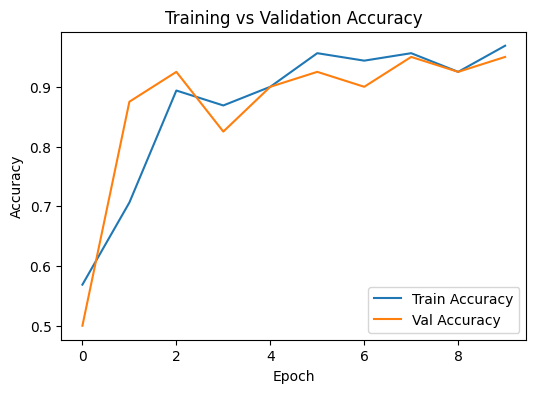

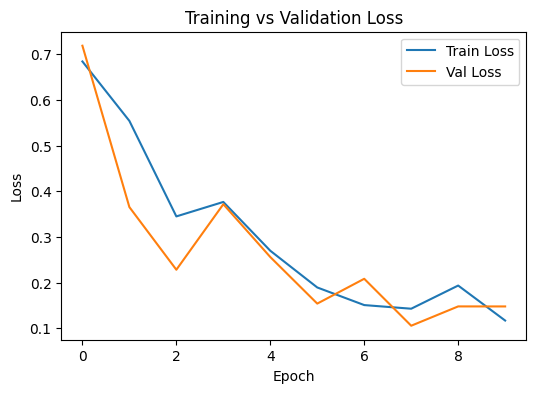

In [159]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

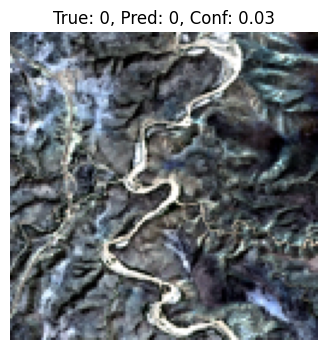

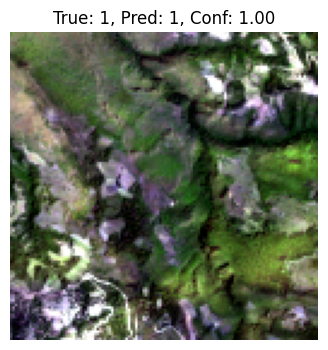

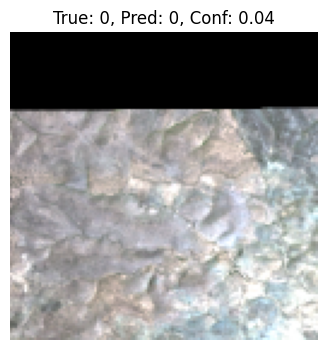

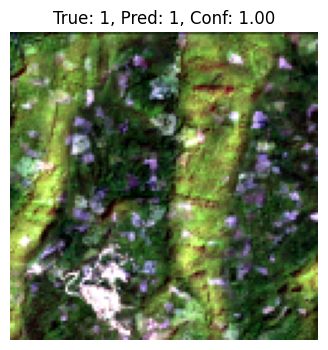

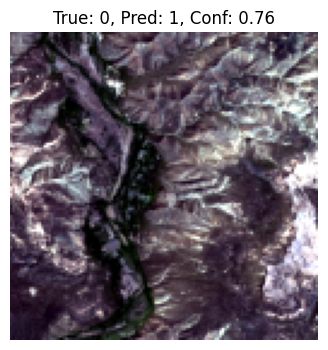

In [160]:
import numpy as np
import matplotlib.pyplot as plt

indices = np.random.choice(len(X_val), 5, replace=False)

for i in indices:
    img = X_val[i]
    true_label = y_val[i]

    pred = model.predict(img[np.newaxis, ...], verbose=0)[0][0]
    pred_label = 1 if pred > 0.5 else 0

    # False color: [NIR, Red, Green] = channels [3,2,1]
    false_color = img[:, :, [3, 2, 1]]

    plt.figure(figsize=(4, 4))
    plt.imshow(false_color)
    plt.title(f"True: {true_label}, Pred: {pred_label}, Conf: {pred:.2f}")
    plt.axis("off")
    plt.show()

# Semi-Supervised

In [161]:
# Preparing unlabeled dataset
import os
import pandas as pd

# All TIFF files
all_tiffs = sorted([
    f for f in os.listdir(input_folder)
    if f.lower().endswith(".tif")
])

# Labeled TIFFs
labeled_set = set(
    labels_df["tile_name"]
    .str.replace("Copy of ", "", regex=False)
    .str.replace(" (1)", "", regex=False)
    .str.replace(" (2)", "", regex=False)
)

# Unlabeled = everything else
unlabeled_files = [f for f in all_tiffs if f not in labeled_set]

print("Total TIFFs:", len(all_tiffs))
print("Labeled:", len(labeled_set))
print("Unlabeled:", len(unlabeled_files))

Total TIFFs: 17161
Labeled: 186
Unlabeled: 16975


In [162]:
# Predict on unlabeled data
import os
import time
import numpy as np

save_folder = "/content/drive/MyDrive/computer_vision/pseudo_cache"
os.makedirs(save_folder, exist_ok=True)

pseudo_X_path = os.path.join(save_folder, "pseudo_X_1000.npy")
pseudo_y_path = os.path.join(save_folder, "pseudo_y_1000.npy")
pseudo_conf_path = os.path.join(save_folder, "pseudo_conf_1000.npy")

if (
    os.path.exists(pseudo_X_path)
    and os.path.exists(pseudo_y_path)
    and os.path.exists(pseudo_conf_path)
):
    print("Saved pseudo-labels found. Loading from Drive...")
    pseudo_X = np.load(pseudo_X_path)
    pseudo_y = np.load(pseudo_y_path)
    pseudo_conf = np.load(pseudo_conf_path)

    print("pseudo_X shape:", pseudo_X.shape)
    print("pseudo_y shape:", pseudo_y.shape)

    if len(pseudo_y) > 0:
        unique, counts = np.unique(pseudo_y, return_counts=True)
        print("Pseudo-label counts:", dict(zip(unique, counts)))
        print("Confidence min:", pseudo_conf.min())
        print("Confidence max:", pseudo_conf.max())

else:
    print("No saved pseudo-labels found. Running pseudo-labeling...")

    # Starting with a manageable subset
    unlabeled_subset = unlabeled_files[:1000]
    print("Subset size:", len(unlabeled_subset))

    pseudo_X = []
    pseudo_y = []
    pseudo_conf = []
    pseudo_names = []

    batch_size = 32
    start_time = time.time()

    POS_THRESH = 0.95
    NEG_THRESH = 0.05
    MAX_PSEUDO_PER_CLASS = 150

    count_pos = 0
    count_neg = 0

    for start_idx in range(0, len(unlabeled_subset), batch_size):
        if count_pos >= MAX_PSEUDO_PER_CLASS and count_neg >= MAX_PSEUDO_PER_CLASS:
            print("Reached max pseudo-label limit for both classes. Stopping early.")
            break

        batch_files = unlabeled_subset[start_idx:start_idx + batch_size]

        batch_imgs = []
        kept_names = []

        for fname in batch_files:
            path = os.path.join(input_folder, fname)
            try:
                img = load_4band_tiff(path, IMG_SIZE)
                batch_imgs.append(img)
                kept_names.append(fname)
            except Exception as e:
                print(f"Skipping {fname}: {e}")

        if len(batch_imgs) == 0:
            print(f"Batch starting at {start_idx}: no valid images")
            continue

        batch_imgs = np.array(batch_imgs, dtype=np.float32)
        preds = model.predict(batch_imgs, verbose=0).flatten()

        accepted_this_batch = 0

        for img, pred, fname in zip(batch_imgs, preds, kept_names):
            if pred > POS_THRESH and count_pos < MAX_PSEUDO_PER_CLASS:
                pseudo_X.append(img)
                pseudo_y.append(1)
                pseudo_conf.append(pred)
                pseudo_names.append(fname)
                count_pos += 1
                accepted_this_batch += 1

            elif pred < NEG_THRESH and count_neg < MAX_PSEUDO_PER_CLASS:
                pseudo_X.append(img)
                pseudo_y.append(0)
                pseudo_conf.append(pred)
                pseudo_names.append(fname)
                count_neg += 1
                accepted_this_batch += 1

        done = min(start_idx + len(batch_files), len(unlabeled_subset))
        elapsed = time.time() - start_time

        print(
            f"Processed {done}/{len(unlabeled_subset)} | "
            f"Accepted so far: {len(pseudo_X)} | "
            f"Accepted this batch: {accepted_this_batch} | "
            f"Class 0: {count_neg} | "
            f"Class 1: {count_pos} | "
            f"Elapsed: {elapsed:.1f}s"
        )

    pseudo_X = np.array(pseudo_X, dtype=np.float32)
    pseudo_y = np.array(pseudo_y, dtype=np.int32)
    pseudo_conf = np.array(pseudo_conf, dtype=np.float32)

    print("\nFinal pseudo-labeled summary")
    print("pseudo_X shape:", pseudo_X.shape)
    print("pseudo_y shape:", pseudo_y.shape)

    if len(pseudo_y) > 0:
        unique, counts = np.unique(pseudo_y, return_counts=True)
        print("Pseudo-label counts:", dict(zip(unique, counts)))
        print("Confidence min:", pseudo_conf.min())
        print("Confidence max:", pseudo_conf.max())
    else:
        print("No pseudo-labels were accepted.")

    # Save to Drive so reruns can skip computation
    np.save(pseudo_X_path, pseudo_X)
    np.save(pseudo_y_path, pseudo_y)
    np.save(pseudo_conf_path, pseudo_conf)

    print("Pseudo-label arrays saved to Drive.")

Saved pseudo-labels found. Loading from Drive...
pseudo_X shape: (300, 128, 128, 4)
pseudo_y shape: (300,)
Pseudo-label counts: {np.int32(0): np.int64(150), np.int32(1): np.int64(150)}
Confidence min: 0.00064048567
Confidence max: 1.0


In [163]:
# Convert to arrays
pseudo_X = np.array(pseudo_X, dtype=np.float32)
pseudo_y = np.array(pseudo_y, dtype=np.int32)

print("Pseudo-labeled samples:", len(pseudo_X))

Pseudo-labeled samples: 300


In [164]:
print("pseudo_X shape:", pseudo_X.shape)
print("pseudo_y shape:", pseudo_y.shape)

if len(pseudo_y) == 0:
    print(" No pseudo-labels found — skipping retraining")

else:
    # Show distribution
    unique, counts = np.unique(pseudo_y, return_counts=True)
    print("Pseudo-label counts:", dict(zip(unique, counts)))

    # Combining datasets
    X_combined = np.concatenate([X_train, pseudo_X], axis=0)
    y_combined = np.concatenate([y_train, pseudo_y], axis=0)

    print("Combined dataset:", X_combined.shape)

    # Retrain model
    history2 = model.fit(
        X_combined, y_combined,
        validation_data=(X_val, y_val),
        epochs=5,
        batch_size=16
    )

    # Evaluate
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    print("New Validation Accuracy:", val_acc)

pseudo_X shape: (300, 128, 128, 4)
pseudo_y shape: (300,)
Pseudo-label counts: {np.int32(0): np.int64(150), np.int32(1): np.int64(150)}
Combined dataset: (460, 128, 128, 4)
Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 530ms/step - accuracy: 0.9848 - loss: 0.0536 - val_accuracy: 0.9750 - val_loss: 0.1153
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 519ms/step - accuracy: 0.9913 - loss: 0.0242 - val_accuracy: 0.9500 - val_loss: 0.0633
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 524ms/step - accuracy: 0.9935 - loss: 0.0200 - val_accuracy: 0.8750 - val_loss: 0.5274
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 521ms/step - accuracy: 0.9978 - loss: 0.0113 - val_accuracy: 0.8250 - val_loss: 0.9787
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 526ms/step - accuracy: 0.9891 - loss: 0.0251 - val_accuracy: 0.9000 - val_loss: 0.2420
New Validation Accuracy: 0.8999999761581421


In [165]:
# Combine datasets
X_combined = np.concatenate([X_train, pseudo_X], axis=0)
y_combined = np.concatenate([y_train, pseudo_y], axis=0)

print("Combined dataset:", X_combined.shape)

Combined dataset: (460, 128, 128, 4)


In [166]:
val_loss, val_acc = model.evaluate(X_val, y_val)
print("New Validation Accuracy:", val_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9000 - loss: 0.2420
New Validation Accuracy: 0.8999999761581421


In [167]:
import os
import time
import gc
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# Paths
input_folder = "/content/drive/MyDrive/computer_vision/tiles_multiband_tif_4band"
save_folder = "/content/drive/MyDrive/computer_vision/pseudo_cache"
os.makedirs(save_folder, exist_ok=True)

IMG_SIZE = 128


# Rebuilding fresh CNN model
def build_cnn_model(img_size=128):
    model = models.Sequential([
        layers.Input(shape=(img_size, img_size, 4)),

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Utility: run pseudo-labeling and save
def generate_pseudo_labels(
    model,
    unlabeled_files,
    input_folder,
    img_size,
    load_4band_tiff,
    max_pseudo_per_class,
    subset_size=1000,
    pos_thresh=0.95,
    neg_thresh=0.05,
    batch_size=32,
    tag="exp"
):
    pseudo_X_path = os.path.join(save_folder, f"pseudo_X_{tag}.npy")
    pseudo_y_path = os.path.join(save_folder, f"pseudo_y_{tag}.npy")
    pseudo_conf_path = os.path.join(save_folder, f"pseudo_conf_{tag}.npy")

    if (
        os.path.exists(pseudo_X_path)
        and os.path.exists(pseudo_y_path)
        and os.path.exists(pseudo_conf_path)
    ):
        print(f"Saved pseudo-labels found for tag='{tag}'. Loading from Drive...")
        pseudo_X = np.load(pseudo_X_path)
        pseudo_y = np.load(pseudo_y_path)
        pseudo_conf = np.load(pseudo_conf_path)

        print("pseudo_X shape:", pseudo_X.shape)
        print("pseudo_y shape:", pseudo_y.shape)

        if len(pseudo_y) > 0:
            unique, counts = np.unique(pseudo_y, return_counts=True)
            print("Pseudo-label counts:", dict(zip(unique, counts)))
            print("Confidence min:", pseudo_conf.min())
            print("Confidence max:", pseudo_conf.max())

        return pseudo_X, pseudo_y, pseudo_conf

    print(f"No saved pseudo-labels found for tag='{tag}'. Running pseudo-labeling...")

    unlabeled_subset = unlabeled_files[:subset_size]
    print("Subset size:", len(unlabeled_subset))

    pseudo_X = []
    pseudo_y = []
    pseudo_conf = []
    pseudo_names = []

    start_time = time.time()
    count_pos = 0
    count_neg = 0

    for start_idx in range(0, len(unlabeled_subset), batch_size):
        if count_pos >= max_pseudo_per_class and count_neg >= max_pseudo_per_class:
            print("Reached max pseudo-label limit for both classes. Stopping early.")
            break

        batch_files = unlabeled_subset[start_idx:start_idx + batch_size]

        batch_imgs = []
        kept_names = []

        for fname in batch_files:
            path = os.path.join(input_folder, fname)
            try:
                img = load_4band_tiff(path, img_size)
                batch_imgs.append(img)
                kept_names.append(fname)
            except Exception as e:
                print(f"Skipping {fname}: {e}")

        if len(batch_imgs) == 0:
            print(f"Batch starting at {start_idx}: no valid images")
            continue

        batch_imgs = np.array(batch_imgs, dtype=np.float32)
        preds = model.predict(batch_imgs, verbose=0).flatten()

        accepted_this_batch = 0

        for img, pred, fname in zip(batch_imgs, preds, kept_names):
            if pred > pos_thresh and count_pos < max_pseudo_per_class:
                pseudo_X.append(img)
                pseudo_y.append(1)
                pseudo_conf.append(pred)
                pseudo_names.append(fname)
                count_pos += 1
                accepted_this_batch += 1

            elif pred < neg_thresh and count_neg < max_pseudo_per_class:
                pseudo_X.append(img)
                pseudo_y.append(0)
                pseudo_conf.append(pred)
                pseudo_names.append(fname)
                count_neg += 1
                accepted_this_batch += 1

        done = min(start_idx + len(batch_files), len(unlabeled_subset))
        elapsed = time.time() - start_time

        print(
            f"Processed {done}/{len(unlabeled_subset)} | "
            f"Accepted so far: {len(pseudo_X)} | "
            f"Accepted this batch: {accepted_this_batch} | "
            f"Class 0: {count_neg} | "
            f"Class 1: {count_pos} | "
            f"Elapsed: {elapsed:.1f}s"
        )

    pseudo_X = np.array(pseudo_X, dtype=np.float32)
    pseudo_y = np.array(pseudo_y, dtype=np.int32)
    pseudo_conf = np.array(pseudo_conf, dtype=np.float32)

    print("\nFinal pseudo-labeled summary")
    print("pseudo_X shape:", pseudo_X.shape)
    print("pseudo_y shape:", pseudo_y.shape)

    if len(pseudo_y) > 0:
        unique, counts = np.unique(pseudo_y, return_counts=True)
        print("Pseudo-label counts:", dict(zip(unique, counts)))
        print("Confidence min:", pseudo_conf.min())
        print("Confidence max:", pseudo_conf.max())
    else:
        print("No pseudo-labels were accepted.")

    np.save(pseudo_X_path, pseudo_X)
    np.save(pseudo_y_path, pseudo_y)
    np.save(pseudo_conf_path, pseudo_conf)

    print(f"Pseudo-label arrays saved to Drive with tag='{tag}'.")

    return pseudo_X, pseudo_y, pseudo_conf



# Utility: retrain and evaluate
def retrain_with_pseudo(model, X_train, y_train, X_val, y_val, pseudo_X, pseudo_y, epochs=5, batch_size=16):
    if len(pseudo_y) == 0:
        print("No pseudo-labels found — skipping retraining")
        return None, None, None

    X_combined = np.concatenate([X_train, pseudo_X], axis=0)
    y_combined = np.concatenate([y_train, pseudo_y], axis=0)

    print("Combined dataset:", X_combined.shape, y_combined.shape)

    history = model.fit(
        X_combined, y_combined,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    print("New Validation Loss:", val_loss)
    print("New Validation Accuracy:", val_acc)

    return history, val_loss, val_acc

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step


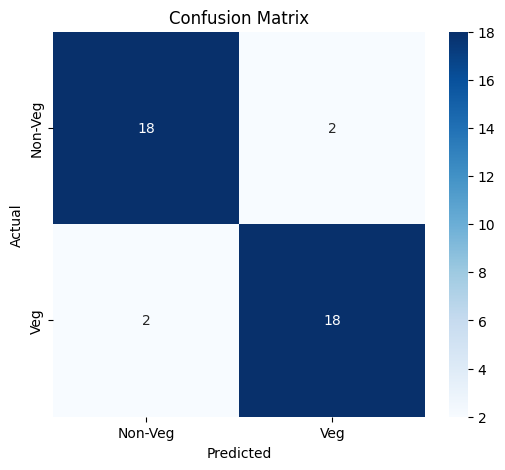

In [168]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Non-Veg", "Veg"],
            yticklabels=["Non-Veg", "Veg"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [169]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred, target_names=["Non-Veg", "Veg"]))

              precision    recall  f1-score   support

     Non-Veg       0.90      0.90      0.90        20
         Veg       0.90      0.90      0.90        20

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40



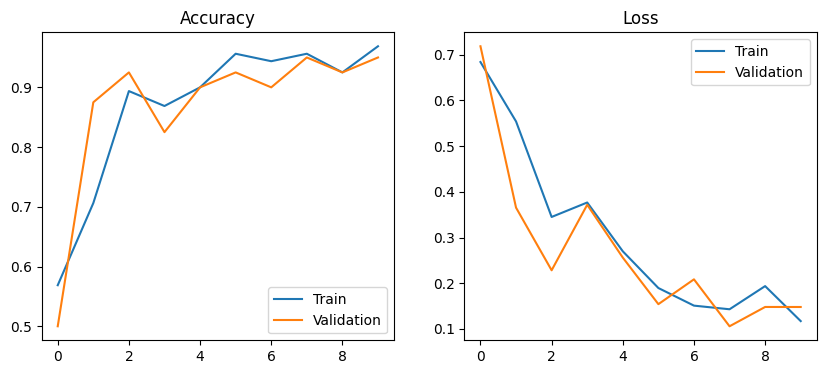

In [170]:
# Accuracy plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.show()

In [171]:
from tensorflow.keras.models import clone_model

model_50 = clone_model(model)
model_50.set_weights(model.get_weights())

model_75 = clone_model(model)
model_75.set_weights(model.get_weights())

In [172]:
pseudo_X_50 = pseudo_X[:50]
pseudo_y_50 = pseudo_y[:50]

pseudo_X_75 = pseudo_X[:75]
pseudo_y_75 = pseudo_y[:75]

In [173]:
history_50, val_loss_50, val_acc_50 = retrain_with_pseudo(
    model=model_50,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    pseudo_X=pseudo_X_50,
    pseudo_y=pseudo_y_50,
    epochs=5,
    batch_size=16
)

Combined dataset: (210, 128, 128, 4) (210,)
Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 458ms/step - accuracy: 0.9048 - loss: 0.3196 - val_accuracy: 0.8000 - val_loss: 0.6265
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 581ms/step - accuracy: 0.9714 - loss: 0.0634 - val_accuracy: 0.9000 - val_loss: 0.1884
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 435ms/step - accuracy: 0.9905 - loss: 0.0265 - val_accuracy: 0.9500 - val_loss: 0.2142
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 611ms/step - accuracy: 0.9905 - loss: 0.0211 - val_accuracy: 0.9000 - val_loss: 0.3511
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 443ms/step - accuracy: 0.9905 - loss: 0.0132 - val_accuracy: 0.9500 - val_loss: 0.1011
New Validation Loss: 0.10109889507293701
New Validation Accuracy: 0.949999988079071


In [174]:
baseline_acc = 0.95        # your baseline CNN result
val_acc_50 = 0.925         # from your 50 experiment
val_acc_300 = 0.875        # from your 300 experiment

In [175]:
import pandas as pd

results = pd.DataFrame({
    "Experiment": ["Baseline CNN", "CNN + 50 pseudo", "CNN + 300 pseudo"],
    "Validation Accuracy": [baseline_acc, val_acc_50, val_acc_300]
})

print(results)

         Experiment  Validation Accuracy
0      Baseline CNN                0.950
1   CNN + 50 pseudo                0.925
2  CNN + 300 pseudo                0.875
